In [ ]:
from algorithms import *
from envs import *
from helpers import visualizer, PolicyEvaluator

/home/sans/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
test_env = BuySellEnv(
    n_states=500,
    max_time=50,
    holding_cost_per_step=0.5,  
    transition_model="brownian",
    transition_params={"mu": 15, "sigma": 10},
)

In [ ]:
# Compare: Model-Based vs LSM vs Q-Learning
from algorithms import ModelBasedAgent, LongstaffSchwartzAgentBuySell, QLearningAgent, linear_decay_schedule
from helpers import PolicyEvaluator

N_EPISODES = 500  # Training budget

# 1. Model-Based
mb_agent = ModelBasedAgent(env=test_env, seed=42)
mb_agent.train(n_episodes=N_EPISODES, verbose=1)
policy_mb = mb_agent.get_policy()
print(f"TPM estimation error (Frobenius): {mb_agent.tpm_error():.4f}")

# 2. LSM        
lsm_agent = LongstaffSchwartzAgentBuySell(env=test_env, poly_degree=3, seed=42)
lsm_agent.train(n_paths=N_EPISODES, seed=42, verbose=False)
policy_lsm = lsm_agent.get_policy()
print("LSM trained.")

# 3. Q-Learning
sched = linear_decay_schedule(1.0, 0.1, N_EPISODES)
ql_agent = QLearningAgent(env=test_env, alpha_schedule=sched, epsilon_schedule=sched, seed=42)
ql_agent.train(env=test_env, n_episodes=N_EPISODES, verbose=0)
policy_ql = ql_agent.get_policy()
print("Q-Learning trained.")

# Optimal
V_opt, Q_opt, policy_opt = test_env.solve_optimal_policy(verbose=False)

  Collected 10/100 episodes
  Collected 20/100 episodes
  Collected 30/100 episodes
  Collected 40/100 episodes
  Collected 50/100 episodes
  Collected 60/100 episodes
  Collected 70/100 episodes
  Collected 80/100 episodes
  Collected 90/100 episodes
  Collected 100/100 episodes
Model-based training complete.
  Total transitions: 417
TPM estimation error (Frobenius): 8.5648
LSM trained.
LSM trained.


Training:   0%|                                                        | 0/100 [00:00<?, ?episode/s]

Q-Learning trained.


Evaluating Model-Based: 100%|██████████| 2000/2000 [00:00<00:00, 6878.06it/s]



Evaluation Summary: Model-Based
Episodes: 2000

Reward Statistics:
  Mean:        121.6795
  Std:          84.8973
  Sharpe:        1.4333
  Median:       88.5000
  Min:          26.5000
  Max:         315.0000

Episode Length:
  Mean:            9.42
  Std:             5.81

Buy-Sell Specific Metrics:
  Completion rate:   100.00%
  Mean buy price:     16.2510
  Mean sell price:   142.1395
  Mean profit:       125.8885
  Mean holding time:     8.42



Evaluating LSM: 100%|██████████| 2000/2000 [00:01<00:00, 1899.78it/s]



Evaluation Summary: LSM
Episodes: 2000

Reward Statistics:
  Mean:        462.1153
  Std:          19.2775
  Sharpe:       23.9717
  Median:      464.5000
  Min:         269.0000
  Max:         485.5000

Episode Length:
  Mean:           35.34
  Std:             4.39

Buy-Sell Specific Metrics:
  Completion rate:   100.00%
  Mean buy price:     16.2510
  Mean sell price:   495.5340
  Mean profit:       479.2830
  Mean holding time:    34.34



Evaluating Q-Learning: 100%|██████████| 2000/2000 [00:00<00:00, 3809.05it/s]



Evaluation Summary: Q-Learning
Episodes: 2000

Reward Statistics:
  Mean:         11.6952
  Std:          11.9791
  Sharpe:        0.9763
  Median:       10.5000
  Min:         -19.5000
  Max:          95.0000

Episode Length:
  Mean:           15.69
  Std:            21.10

Buy-Sell Specific Metrics:
  Completion rate:   73.10%
  Mean buy price:     27.5397
  Mean sell price:    44.0999
  Mean profit:        16.5602
  Mean holding time:     1.12



Evaluating Optimal: 100%|██████████| 2000/2000 [00:01<00:00, 1744.00it/s]




Evaluation Summary: Optimal
Episodes: 2000

Reward Statistics:
  Mean:        464.4223
  Std:           9.0925
  Sharpe:       51.0773
  Median:      465.0000
  Min:         431.0000
  Max:         485.0000

Episode Length:
  Mean:           35.71
  Std:             4.54

Buy-Sell Specific Metrics:
  Completion rate:   100.00%
  Mean buy price:     16.2510
  Mean sell price:   498.0305
  Mean profit:       481.7795
  Mean holding time:    34.71


Policy Comparison: Model-Based vs LSM vs Q-Learning vs Optimal

Metric                     Model-Based          LSM   Q-Learning      Optimal           Best
--------------------------------------------------------------------------------
Mean Reward                   121.6795     462.1153      11.6952     464.4223        Optimal
Std Reward                     84.8973      19.2775      11.9791       9.0925        Optimal
Sharpe Ratio                    1.4333      23.9717       0.9763      51.0773        Optimal
Median Reward                  

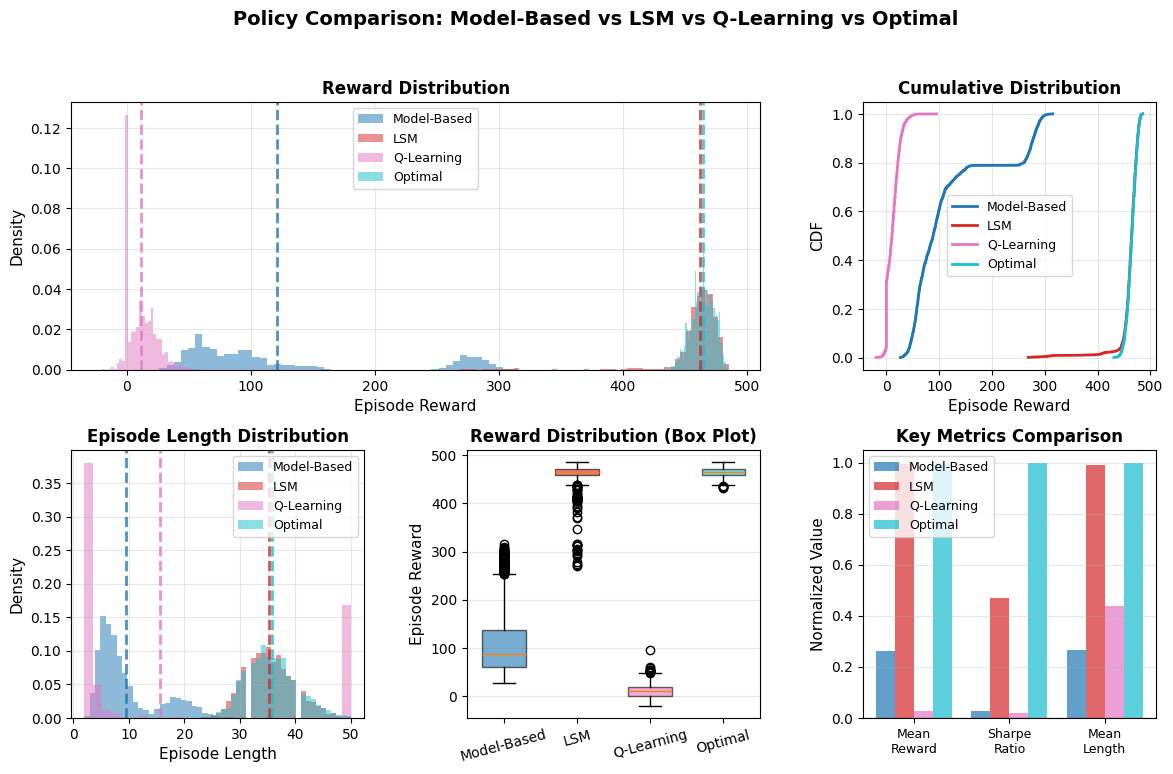

In [ ]:
# Evaluate all methods
evaluator = PolicyEvaluator(test_env)
evaluator.compare_policies(
    policies=[policy_mb, policy_lsm, policy_ql, policy_opt],
    policy_names=["Model-Based", "LSM", "Q-Learning", "Optimal"],
    n_episodes=2000,
    verbose=True
)
evaluator.plot_comparison()